# Design a Machine Learning Approach to Analyse Students’ Performance Based on Their Socio-economic Status in the Kingdom of Bahrain

**MSc Artificial Intelligence — Bahrain Polytechnic**  
**Student: Jaafar Ahmed | ID: 202508989**

# Phase 5 — Unsupervised Learning Analysis

This phase discovers natural socio-economic and educational profiles within the Phase 3 training data without using the academic-performance target during clustering.

## Core safeguards

- Only the Phase 3 training dataset is used.
- The untouched Phase 3 holdout test set remains unopened.
- `academic_performance_class` is excluded from preprocessing, PCA, cluster-number selection, and K-Means fitting.
- `family_id` and `student_record_id` are excluded from clustering.
- The target is added only after clustering for interpretation.
- Cluster labels are descriptive profiles, not judgments about individual students.

## Phase 5 Workflow

```text
Phase 3 Training Dataset
        ↓
Remove identifiers, group variable, and target
        ↓
Encode and scale clustering variables
        ↓
PCA dimensionality reduction
        ↓
Compare K = 2 to 8
        ↓
Select K using multiple internal metrics
        ↓
Fit final K-Means model
        ↓
Evaluate stability and profile clusters
        ↓
Add target only for post-clustering interpretation
        ↓
Export cluster assignments, models, reports, and Phase 6 handoff
```

# Section 5.1 — Load Phase 3 and Phase 4 Outputs

**Purpose:** Configure the environment, locate the Phase 4 handoff for Phase 5, load the Phase 3 training dataset and the Phase 4 supervised leaderboard, and confirm that the holdout test remains unused.

In [1]:
# Cell 5.1.1 — Configure Environment, Project Folders, and Core Functions

from pathlib import Path
from datetime import datetime
import hashlib
import importlib.util
import inspect
import json
import math
import os
import random
import re
import shutil
import subprocess
import sys
import warnings
import zipfile

# -----------------------------------------------------------------------------
# CHANGE THESE SETTINGS ONLY
# -----------------------------------------------------------------------------
EXECUTION_ENVIRONMENT = "COLAB"  # "COLAB", "ANACONDA", or "VSCODE"

PHASE_4_MANIFEST_OVERRIDE = None
TRAINING_DATA_OVERRIDE = None
SCALE_PREPROCESSOR_OVERRIDE = None

PCA_VARIANCE_THRESHOLD = 0.90
MIN_CLUSTERS = 2
MAX_CLUSTERS = 8
KMEANS_N_INIT = 10
STABILITY_RUNS = 5
AUTO_INSTALL_MISSING_PACKAGES = True

# Limit numerical-library threads for stable and reproducible execution.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
# -----------------------------------------------------------------------------

PROJECT_TITLE = (
    "Design a Machine Learning Approach to Analyse Students’ Performance "
    "Based on Their Socio-economic Status in the Kingdom of Bahrain"
)
PROGRAMME = "MSc Artificial Intelligence — Bahrain Polytechnic"
STUDENT_NAME = "Jaafar Ahmed"
STUDENT_ID = "202508989"

RANDOM_STATE = 42
random.seed(RANDOM_STATE)

EXECUTION_ENVIRONMENT = EXECUTION_ENVIRONMENT.strip().upper()
if EXECUTION_ENVIRONMENT not in {"COLAB", "ANACONDA", "VSCODE"}:
    raise ValueError("Invalid execution environment.")

if EXECUTION_ENVIRONMENT == "COLAB":
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        PROJECT_ROOT = Path("/content/drive/MyDrive/Jaafar_MSc_Thesis")
    except ImportError:
        PROJECT_ROOT = Path.cwd()
        print("Google Colab is unavailable; using:", PROJECT_ROOT)
else:
    PROJECT_ROOT = Path.cwd()

SOURCE_DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR = SOURCE_DATA_DIR
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
PHASE_3_DIR = OUTPUT_ROOT / "Phase_03_Train_Test_Split_and_Preprocessing_Pipelines"
PHASE_4_DIR = OUTPUT_ROOT / "Phase_04_Supervised_Learning_Algorithms"
PHASE_DIR = OUTPUT_ROOT / "Phase_05_Unsupervised_Learning_Analysis"
MODEL_DIR = PHASE_DIR / "models"


def ensure_writable_folder(folder):
    """Create a folder and confirm that the current runtime can write to it."""
    folder.mkdir(parents=True, exist_ok=True)
    test_path = folder / ".phase_05_write_test"
    test_path.write_text("test", encoding="utf-8")
    test_path.unlink()


try:
    for folder in [DATA_DIR, OUTPUT_ROOT, PHASE_DIR, MODEL_DIR]:
        ensure_writable_folder(folder)
except (PermissionError, OSError):
    print(
        "The standard project output folders are not writable in this runtime. "
        "Using portable Phase 5 folders instead."
    )
    DATA_DIR = PROJECT_ROOT / "phase_05_data"
    OUTPUT_ROOT = PROJECT_ROOT / "phase_05_outputs"
    PHASE_DIR = OUTPUT_ROOT / "Phase_05_Unsupervised_Learning_Analysis"
    MODEL_DIR = PHASE_DIR / "models"

    for folder in [DATA_DIR, OUTPUT_ROOT, PHASE_DIR, MODEL_DIR]:
        ensure_writable_folder(folder)

RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")


def safe_name(text):
    """Convert text to a safe file or folder name."""
    text = str(text).strip().replace("—", "-").replace("–", "-")
    text = re.sub(r"[^\w\-]+", "_", text, flags=re.UNICODE)
    return re.sub(r"_+", "_", text).strip("_") or "Unnamed"


def create_cell_folders(section_number, section_title, cell_number, cell_title):
    """Create the approved Phase → Section → Cell hierarchy."""
    base = (
        PHASE_DIR
        / safe_name(f"Section_{section_number}_{section_title}")
        / safe_name(f"Cell_{cell_number}_{cell_title}")
    )
    folders = {
        "tables": base / "tables",
        "figures": base / "figures",
        "reports": base / "reports",
        "models": base / "models",
        "files": base / "files",
    }
    for folder in folders.values():
        folder.mkdir(parents=True, exist_ok=True)
    return folders


def save_dataframe(dataframe, folders, file_stem, index=False):
    """Save a table as UTF-8 CSV."""
    path = folders["tables"] / f"{file_stem}.csv"
    dataframe.to_csv(path, index=index, encoding="utf-8-sig")
    return path


def save_json_report(data, folders, file_stem):
    """Save a JSON report."""
    path = folders["reports"] / f"{file_stem}.json"
    with path.open("w", encoding="utf-8") as file:
        json.dump(data, file, ensure_ascii=False, indent=2, default=str)
    return path


def sha256_file(path):
    """Calculate a SHA-256 hash."""
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def load_table(path):
    """Load CSV or Excel input."""
    path = Path(path)
    if path.suffix.lower() == ".csv":
        try:
            return pd.read_csv(path, encoding="utf-8-sig")
        except UnicodeDecodeError:
            return pd.read_csv(path, encoding="latin-1")
    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported input format: {path.suffix}")


CELL_FOLDERS = create_cell_folders(
    "05_01",
    "Load_Phase_3_and_Phase_4_Outputs",
    "05_01_01",
    "Configure_Environment_Project_Folders_and_Core_Functions",
)

project_configuration = {
    "project_title": PROJECT_TITLE,
    "programme": PROGRAMME,
    "student_name": STUDENT_NAME,
    "student_id": STUDENT_ID,
    "execution_environment": EXECUTION_ENVIRONMENT,
    "project_root": str(PROJECT_ROOT),
    "phase_5_directory": str(PHASE_DIR),
    "pca_variance_threshold": PCA_VARIANCE_THRESHOLD,
    "minimum_clusters": MIN_CLUSTERS,
    "maximum_clusters": MAX_CLUSTERS,
    "kmeans_n_init": KMEANS_N_INIT,
    "stability_runs": STABILITY_RUNS,
    "random_state": RANDOM_STATE,
    "run_timestamp": RUN_TIMESTAMP,
}

save_json_report(
    project_configuration,
    CELL_FOLDERS,
    "05_01_01_project_configuration",
)

print("Project root:", PROJECT_ROOT)
print("Phase 5 folder:", PHASE_DIR)

Google Colab is unavailable; using: C:\Users\User\Desktop\All
Project root: C:\Users\User\Desktop\All
Phase 5 folder: C:\Users\User\Desktop\All\outputs\Phase_05_Unsupervised_Learning_Analysis


In [2]:
# Cell 5.1.2 — Check Libraries and Define the Thesis Visual Identity

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
}

installation_rows = []

for import_name, package_name in required_packages.items():
    installed = importlib.util.find_spec(import_name) is not None

    if installed:
        status = "Already installed"
    elif AUTO_INSTALL_MISSING_PACKAGES:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", package_name]
        )
        status = "Installed during this run"
    else:
        raise ImportError(f"Missing package: {package_name}")

    installation_rows.append(
        {
            "import_name": import_name,
            "package_name": package_name,
            "status": status,
        }
    )

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import scipy
import sklearn

from scipy.stats import chi2_contingency
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("default")
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 160)
pd.set_option("display.width", 210)

THEME = {
    "maroon": "#6B1E32",
    "deep_maroon": "#43101F",
    "gold": "#D4A64A",
    "teal": "#237A7A",
    "coral": "#D96850",
    "indigo": "#525B92",
    "sage": "#7A9B76",
    "sand": "#D9C7A3",
    "warm_white": "#F7F4EF",
    "charcoal": "#2E3035",
    "soft_grey": "#D8D5D0",
    "light_maroon": "#B77987",
}

CLUSTER_COLORS = [
    THEME["maroon"],
    THEME["gold"],
    THEME["teal"],
    THEME["coral"],
    THEME["indigo"],
    THEME["sage"],
    "#965D41",
    "#7A4E9D",
]

CLASS_COLORS = {
    "Low": THEME["coral"],
    "Medium": THEME["gold"],
    "High": THEME["teal"],
}

mpl.rcParams.update(
    {
        "figure.facecolor": THEME["warm_white"],
        "axes.facecolor": THEME["warm_white"],
        "savefig.facecolor": THEME["warm_white"],
        "text.color": THEME["charcoal"],
        "axes.labelcolor": THEME["charcoal"],
        "xtick.color": THEME["charcoal"],
        "ytick.color": THEME["charcoal"],
        "font.size": 10,
        "axes.titleweight": "bold",
        "axes.titlesize": 15,
        "legend.frameon": False,
    }
)


def style_axis(axis, title, subtitle=None, grid_axis="y"):
    """Apply the project visual identity."""
    axis.set_title(title, loc="left", pad=18, fontweight="bold")
    if subtitle:
        axis.text(
            0,
            1.015,
            subtitle,
            transform=axis.transAxes,
            fontsize=9,
            color="#5B5B5B",
            va="bottom",
        )
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_alpha(0.35)
    axis.spines["bottom"].set_alpha(0.35)
    if grid_axis:
        axis.grid(axis=grid_axis, alpha=0.16)
    axis.set_axisbelow(True)


def save_figure(figure, folders, file_stem):
    """Save one 300-DPI thesis-quality figure."""
    path = folders["figures"] / f"{file_stem}.png"
    figure.text(
        0.01,
        0.01,
        "MSc Artificial Intelligence — Bahrain Polytechnic | Phase 5",
        fontsize=7.5,
        color="#666666",
    )
    figure.savefig(path, dpi=300, bbox_inches="tight")
    return path


CELL_FOLDERS = create_cell_folders(
    "05_01",
    "Load_Phase_3_and_Phase_4_Outputs",
    "05_01_02",
    "Check_Libraries_and_Define_the_Thesis_Visual_Identity",
)

installation_report = pd.DataFrame(installation_rows)
library_versions = pd.DataFrame(
    [
        ["Python", sys.version.split()[0]],
        ["pandas", pd.__version__],
        ["numpy", np.__version__],
        ["scipy", scipy.__version__],
        ["matplotlib", mpl.__version__],
        ["scikit-learn", sklearn.__version__],
        ["joblib", joblib.__version__],
    ],
    columns=["library", "version"],
)

save_dataframe(
    installation_report,
    CELL_FOLDERS,
    "05_01_02_library_installation_report",
)
save_dataframe(
    library_versions,
    CELL_FOLDERS,
    "05_01_02_library_versions",
)

display(library_versions)

,library,version
0,Python,3.13.5
1,pandas,2.2.3
2,numpy,2.1.3
3,scipy,1.15.3
4,matplotlib,3.10.0
5,scikit-learn,1.6.1
6,joblib,1.4.2


In [3]:
# Cell 5.1.3 — Locate Phase 4 Handoff, Training Data, and Preprocessing Template

CELL_FOLDERS = create_cell_folders(
    "05_01",
    "Load_Phase_3_and_Phase_4_Outputs",
    "05_01_03",
    "Locate_Phase_4_Handoff_Training_Data_and_Preprocessing_Template",
)


def first_existing(candidates, description):
    """Return the first existing portable path."""
    for candidate in candidates:
        if candidate is None:
            continue
        candidate = Path(candidate).expanduser()
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not locate {description}.")


manifest_candidates = [
    PHASE_4_MANIFEST_OVERRIDE,
    PHASE_4_DIR / "phase_04_handoff_manifest_for_phase_05.json",
    OUTPUT_ROOT / "phase_04_handoff_manifest_for_phase_05.json",
    PROJECT_ROOT / "phase_04_handoff_manifest_for_phase_05.json",
    Path.cwd() / "phase_04_handoff_manifest_for_phase_05.json",
]

if PHASE_4_DIR.exists():
    manifest_candidates.extend(
        PHASE_4_DIR.rglob("phase_04_handoff_manifest_for_phase_05.json")
    )

PHASE_4_MANIFEST_PATH = first_existing(
    manifest_candidates,
    "Phase 4 handoff for Phase 5",
)

with PHASE_4_MANIFEST_PATH.open("r", encoding="utf-8") as file:
    phase_4_manifest = json.load(file)

training_candidates = [
    TRAINING_DATA_OVERRIDE,
    phase_4_manifest.get("training_dataset"),
    phase_4_manifest.get("phase_3_training_dataset"),
    SOURCE_DATA_DIR / "phase_03_training_dataset_for_phase_04.csv",
    Path.cwd() / "data" / "phase_03_training_dataset_for_phase_04.csv",
]

TRAINING_DATA_PATH = first_existing(
    training_candidates,
    "Phase 3 training dataset",
)

scale_candidates = [
    SCALE_PREPROCESSOR_OVERRIDE,
    PROJECT_ROOT / "shared_project_files"
    / "phase_03_scale_sensitive_preprocessor_unfitted.joblib",
    PROJECT_ROOT / "phase_03_scale_sensitive_preprocessor_unfitted.joblib",
    Path.cwd() / "phase_03_scale_sensitive_preprocessor_unfitted.joblib",
]

if PHASE_3_DIR.exists():
    scale_candidates.extend(
        PHASE_3_DIR.rglob(
            "phase_03_scale_sensitive_preprocessor_unfitted.joblib"
        )
    )

SCALE_PREPROCESSOR_PATH = first_existing(
    scale_candidates,
    "Phase 3 scale-sensitive preprocessing template",
)

training_data = load_table(TRAINING_DATA_PATH)
clustering_preprocessor_template = joblib.load(
    SCALE_PREPROCESSOR_PATH
)

leaderboard_path = phase_4_manifest.get(
    "supervised_leaderboard_for_context"
) or phase_4_manifest.get("leaderboard")

if leaderboard_path and Path(leaderboard_path).exists():
    supervised_leaderboard = load_table(leaderboard_path)
else:
    supervised_leaderboard = pd.DataFrame()

if training_data.empty:
    raise ValueError("The Phase 3 training dataset is empty.")

loading_summary = {
    "phase_4_manifest": str(PHASE_4_MANIFEST_PATH),
    "training_dataset": str(TRAINING_DATA_PATH),
    "training_sha256": sha256_file(TRAINING_DATA_PATH),
    "training_records": int(len(training_data)),
    "preprocessing_template": str(SCALE_PREPROCESSOR_PATH),
    "supervised_leaderboard_loaded": not supervised_leaderboard.empty,
    "holdout_test_used": False,
}

save_json_report(
    loading_summary,
    CELL_FOLDERS,
    "05_01_03_loading_summary",
)

print("Training shape:", training_data.shape)
print("Holdout loaded:", False)

Training shape: (2006, 20)
Holdout loaded: False


# Section 5.2 — Clustering Data Preparation

**Purpose:** Separate clustering predictors from identifiers, family grouping, and the target; validate the clustering matrix; fit the Phase 3 preprocessing template on training predictors only.

In [4]:
# Cell 5.2.1 — Define Clustering Variables and Exclude Target and Identifiers

CELL_FOLDERS = create_cell_folders(
    "05_02",
    "Clustering_Data_Preparation",
    "05_02_01",
    "Define_Clustering_Variables_and_Exclude_Target_and_Identifiers",
)

ID_COLUMN = "student_record_id"
GROUP_COLUMN = phase_4_manifest.get("group_column", "family_id")
TARGET_COLUMN = (
    phase_4_manifest.get("target_column_for_post_clustering_interpretation")
    or phase_4_manifest.get("target_for_post_clustering_interpretation")
    or "academic_performance_class"
)

PREDICTOR_COLUMNS = (
    phase_4_manifest.get("structured_predictors")
    or phase_4_manifest.get("predictor_columns")
    or phase_4_manifest.get("predictors")
)

if PREDICTOR_COLUMNS is None:
    PREDICTOR_COLUMNS = [
        column
        for column in training_data.columns
        if column not in {ID_COLUMN, GROUP_COLUMN, TARGET_COLUMN}
    ]

required_columns = [
    ID_COLUMN,
    GROUP_COLUMN,
    *PREDICTOR_COLUMNS,
    TARGET_COLUMN,
]

missing_columns = sorted(
    set(required_columns) - set(training_data.columns)
)

if missing_columns:
    raise ValueError(
        "Missing required columns: " + ", ".join(missing_columns)
    )

X_clustering_raw = training_data[PREDICTOR_COLUMNS].copy()
record_ids = training_data[ID_COLUMN].astype(str).copy()
family_groups = training_data[GROUP_COLUMN].copy()
target_for_later_interpretation = training_data[
    TARGET_COLUMN
].astype(str).copy()

if X_clustering_raw.isna().sum().sum() != 0:
    raise ValueError(
        "The Phase 3 clustering predictors should not contain missing values."
    )

role_table = pd.DataFrame(
    [
        {
            "variable": column,
            "role_in_phase_5": (
                "Identifier — excluded"
                if column == ID_COLUMN
                else "Family group — excluded"
                if column == GROUP_COLUMN
                else "Target — excluded until interpretation"
                if column == TARGET_COLUMN
                else "Clustering predictor"
            ),
            "used_for_kmeans": column in PREDICTOR_COLUMNS,
        }
        for column in required_columns
    ]
)

preparation_summary = pd.DataFrame(
    [
        ["Training records", len(training_data)],
        ["Clustering predictors", len(PREDICTOR_COLUMNS)],
        ["Identifiers used in clustering", 0],
        ["Group variables used in clustering", 0],
        ["Target variables used in clustering", 0],
        ["Missing predictor cells", int(X_clustering_raw.isna().sum().sum())],
    ],
    columns=["preparation_measure", "value"],
)

save_dataframe(
    role_table,
    CELL_FOLDERS,
    "05_02_01_variable_roles",
)
save_dataframe(
    preparation_summary,
    CELL_FOLDERS,
    "05_02_01_clustering_preparation_summary",
)

display(preparation_summary)
display(role_table)

,preparation_measure,value
0,Training records,2006
1,Clustering predictors,17
2,Identifiers used in clustering,0
3,Group variables used in clustering,0
4,Target variables used in clustering,0
5,Missing predictor cells,0


,variable,role_in_phase_5,used_for_kmeans
0,student_record_id,Identifier — excluded,False
1,family_id,Family group — excluded,False
2,father_alive,Clustering predictor,True
3,mother_alive,Clustering predictor,True
4,father_education,Clustering predictor,True
5,mother_education,Clustering predictor,True
6,father_job,Clustering predictor,True
7,mother_job,Clustering predictor,True
8,marital_status,Clustering predictor,True
9,family_income,Clustering predictor,True


In [5]:
# Cell 5.2.2 — Fit the Training-Only Clustering Preprocessor

CELL_FOLDERS = create_cell_folders(
    "05_02",
    "Clustering_Data_Preparation",
    "05_02_02",
    "Fit_the_Training_Only_Clustering_Preprocessor",
)

clustering_preprocessor = clone(clustering_preprocessor_template)
X_transformed = clustering_preprocessor.fit_transform(
    X_clustering_raw
)

if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

X_transformed = np.asarray(X_transformed, dtype=float)

if not np.isfinite(X_transformed).all():
    raise ValueError(
        "The transformed clustering matrix contains non-finite values."
    )

transformed_feature_names = (
    clustering_preprocessor.get_feature_names_out()
)

transformed_feature_table = pd.DataFrame(
    {
        "feature_number": np.arange(
            1,
            len(transformed_feature_names) + 1,
        ),
        "transformed_feature": transformed_feature_names,
    }
)

transformation_summary = pd.DataFrame(
    [
        ["Input records", X_clustering_raw.shape[0]],
        ["Original predictors", X_clustering_raw.shape[1]],
        ["Transformed features", X_transformed.shape[1]],
        ["Finite transformed cells", bool(np.isfinite(X_transformed).all())],
        ["Target included in matrix", False],
        ["Family ID included in matrix", False],
    ],
    columns=["transformation_measure", "value"],
)

PREPROCESSOR_MODEL_PATH = (
    MODEL_DIR / "phase_05_fitted_clustering_preprocessor.joblib"
)
joblib.dump(
    clustering_preprocessor,
    PREPROCESSOR_MODEL_PATH,
)

save_dataframe(
    transformed_feature_table,
    CELL_FOLDERS,
    "05_02_02_transformed_feature_names",
)
save_dataframe(
    transformation_summary,
    CELL_FOLDERS,
    "05_02_02_transformation_summary",
)

display(transformation_summary)

,transformation_measure,value
0,Input records,2006
1,Original predictors,17
2,Transformed features,26
3,Finite transformed cells,True
4,Target included in matrix,False
5,Family ID included in matrix,False


# Section 5.3 — Dimensionality Reduction

**Purpose:** Use Principal Component Analysis to reduce correlated encoded features while retaining at least 90% of the transformed variance, and create a separate two-component projection for visual interpretation.

In [6]:
# Cell 5.3.1 — Fit PCA and Select Components by Explained Variance

CELL_FOLDERS = create_cell_folders(
    "05_03",
    "Dimensionality_Reduction",
    "05_03_01",
    "Fit_PCA_and_Select_Components_by_Explained_Variance",
)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_transformed)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

selected_component_count = int(
    np.argmax(cumulative_variance >= PCA_VARIANCE_THRESHOLD) + 1
)

pca_selected = PCA(
    n_components=selected_component_count,
    random_state=RANDOM_STATE,
)
X_pca = pca_selected.fit_transform(X_transformed)

pca_two_dimensions = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)
X_pca_2d = pca_two_dimensions.fit_transform(
    X_transformed
)

pca_variance_table = pd.DataFrame(
    {
        "principal_component": np.arange(
            1,
            len(pca_full.explained_variance_ratio_) + 1,
        ),
        "explained_variance_ratio": pca_full.explained_variance_ratio_,
        "cumulative_explained_variance": cumulative_variance,
    }
)

pca_summary = pd.DataFrame(
    [
        ["Transformed features", X_transformed.shape[1]],
        ["Selected PCA components", selected_component_count],
        [
            "Variance threshold",
            PCA_VARIANCE_THRESHOLD,
        ],
        [
            "Retained cumulative variance",
            pca_selected.explained_variance_ratio_.sum(),
        ],
        [
            "Two-dimensional visual variance",
            pca_two_dimensions.explained_variance_ratio_.sum(),
        ],
    ],
    columns=["pca_measure", "value"],
)

PCA_MODEL_PATH = MODEL_DIR / "phase_05_selected_pca.joblib"
PCA_2D_MODEL_PATH = MODEL_DIR / "phase_05_two_dimensional_pca.joblib"

joblib.dump(pca_selected, PCA_MODEL_PATH)
joblib.dump(pca_two_dimensions, PCA_2D_MODEL_PATH)

save_dataframe(
    pca_variance_table,
    CELL_FOLDERS,
    "05_03_01_pca_explained_variance",
)
save_dataframe(
    pca_summary,
    CELL_FOLDERS,
    "05_03_01_pca_summary",
)

display(pca_summary)

,pca_measure,value
0,Transformed features,26.000000
1,Selected PCA components,11.000000
2,Variance threshold,0.900000
3,Retained cumulative variance,0.910408
4,Two-dimensional visual variance,0.467118


# Section 5.4 — Select the Number of Clusters

**Purpose:** Compare cluster counts from 2 to 8 using inertia, Silhouette Score, Calinski–Harabasz Score, and Davies–Bouldin Score. The final count is selected by a transparent composite ranking rather than by the number of target classes.

In [7]:
# Cell 5.4.1 — Evaluate Candidate Cluster Counts

CELL_FOLDERS = create_cell_folders(
    "05_04",
    "Select_the_Number_of_Clusters",
    "05_04_01",
    "Evaluate_Candidate_Cluster_Counts",
)

candidate_rows = []
candidate_labels = {}

for number_of_clusters in range(
    MIN_CLUSTERS,
    MAX_CLUSTERS + 1,
):
    candidate_model = KMeans(
        n_clusters=number_of_clusters,
        init="k-means++",
        n_init=KMEANS_N_INIT,
        max_iter=300,
        random_state=RANDOM_STATE,
    )
    labels = candidate_model.fit_predict(X_pca)
    candidate_labels[number_of_clusters] = labels

    candidate_rows.append(
        {
            "number_of_clusters": number_of_clusters,
            "inertia": float(candidate_model.inertia_),
            "silhouette_score": float(
                silhouette_score(
                    X_pca,
                    labels,
                    sample_size=min(1000, len(X_pca)),
                    random_state=RANDOM_STATE,
                )
            ),
            "calinski_harabasz_score": float(
                calinski_harabasz_score(X_pca, labels)
            ),
            "davies_bouldin_score": float(
                davies_bouldin_score(X_pca, labels)
            ),
            "minimum_cluster_size": int(
                pd.Series(labels).value_counts().min()
            ),
            "maximum_cluster_size": int(
                pd.Series(labels).value_counts().max()
            ),
        }
    )

cluster_number_evaluation = pd.DataFrame(candidate_rows)

cluster_number_evaluation["silhouette_rank"] = (
    cluster_number_evaluation["silhouette_score"]
    .rank(ascending=False, method="min")
)
cluster_number_evaluation["calinski_rank"] = (
    cluster_number_evaluation["calinski_harabasz_score"]
    .rank(ascending=False, method="min")
)
cluster_number_evaluation["davies_rank"] = (
    cluster_number_evaluation["davies_bouldin_score"]
    .rank(ascending=True, method="min")
)

# The elbow is approximated by the largest second difference in inertia.
inertia_values = cluster_number_evaluation["inertia"].to_numpy()
second_difference = np.full(len(inertia_values), np.nan)

if len(inertia_values) >= 3:
    second_difference[1:-1] = np.diff(
        inertia_values,
        n=2,
    )

cluster_number_evaluation[
    "inertia_second_difference"
] = second_difference

valid_elbow = cluster_number_evaluation.dropna(
    subset=["inertia_second_difference"]
)

if valid_elbow.empty:
    elbow_cluster_count = int(
        cluster_number_evaluation.iloc[0][
            "number_of_clusters"
        ]
    )
else:
    elbow_cluster_count = int(
        valid_elbow.loc[
            valid_elbow["inertia_second_difference"].idxmax(),
            "number_of_clusters",
        ]
    )

cluster_number_evaluation["elbow_distance"] = (
    cluster_number_evaluation["number_of_clusters"]
    - elbow_cluster_count
).abs()
cluster_number_evaluation["elbow_rank"] = (
    cluster_number_evaluation["elbow_distance"]
    .rank(ascending=True, method="min")
)

cluster_number_evaluation["composite_rank_score"] = (
    cluster_number_evaluation[
        [
            "silhouette_rank",
            "calinski_rank",
            "davies_rank",
            "elbow_rank",
        ]
    ].sum(axis=1)
)

selected_row = cluster_number_evaluation.sort_values(
    [
        "composite_rank_score",
        "silhouette_rank",
        "davies_rank",
        "number_of_clusters",
    ]
).iloc[0]

SELECTED_CLUSTER_COUNT = int(
    selected_row["number_of_clusters"]
)

cluster_selection_summary = {
    "candidate_range": [
        MIN_CLUSTERS,
        MAX_CLUSTERS,
    ],
    "elbow_cluster_count": elbow_cluster_count,
    "selected_cluster_count": SELECTED_CLUSTER_COUNT,
    "selection_method": (
        "Lowest composite rank across Silhouette, Calinski–Harabasz, "
        "Davies–Bouldin, and elbow proximity"
    ),
    "selected_metrics": {
        "silhouette_score": float(
            selected_row["silhouette_score"]
        ),
        "calinski_harabasz_score": float(
            selected_row["calinski_harabasz_score"]
        ),
        "davies_bouldin_score": float(
            selected_row["davies_bouldin_score"]
        ),
        "inertia": float(selected_row["inertia"]),
    },
    "target_used_in_selection": False,
}

save_dataframe(
    cluster_number_evaluation,
    CELL_FOLDERS,
    "05_04_01_cluster_number_evaluation",
)
save_json_report(
    cluster_selection_summary,
    CELL_FOLDERS,
    "05_04_01_cluster_selection_summary",
)

display(
    cluster_number_evaluation.round(4)
)
print("Selected cluster count:", SELECTED_CLUSTER_COUNT)

,number_of_clusters,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score,minimum_cluster_size,maximum_cluster_size,silhouette_rank,calinski_rank,davies_rank,inertia_second_difference,elbow_distance,elbow_rank,composite_rank_score
0,2,13710.7173,0.1805,475.4844,1.9534,770,1236,1.0,2.0,7.0,NaN,1,2.0,12.0
1,3,11420.4769,0.1799,486.1135,1.6629,537,745,2.0,1.0,2.0,1331.2265,0,1.0,6.0
2,4,10461.4629,0.1623,414.7826,1.7618,357,653,4.0,3.0,4.0,275.0716,1,2.0,13.0
3,5,9777.5206,0.1653,367.6741,1.6388,132,619,3.0,4.0,1.0,76.5208,2,4.0,12.0
4,6,9170.0991,0.1502,339.9619,1.7525,128,397,5.0,5.0,3.0,264.2361,3,5.0,18.0
5,7,8826.9137,0.1329,307.1224,1.9355,129,361,6.0,6.0,5.0,31.7374,4,6.0,23.0
6,8,8515.4657,0.1251,283.1788,1.9484,113,317,7.0,7.0,6.0,NaN,5,7.0,27.0


Selected cluster count: 3


# Section 5.5 — K-Means Clustering

**Purpose:** Fit the final K-Means model using the selected number of clusters, calculate distances to all centroids, and export the core cluster assignments.

In [8]:
# Cell 5.5.1 — Fit the Final K-Means Model and Assign Clusters

CELL_FOLDERS = create_cell_folders(
    "05_05",
    "K_Means_Clustering",
    "05_05_01",
    "Fit_the_Final_K_Means_Model_and_Assign_Clusters",
)

final_kmeans = KMeans(
    n_clusters=SELECTED_CLUSTER_COUNT,
    init="k-means++",
    n_init=KMEANS_N_INIT,
    max_iter=300,
    random_state=RANDOM_STATE,
)

cluster_labels_zero_based = final_kmeans.fit_predict(
    X_pca
)
cluster_labels = cluster_labels_zero_based + 1

distances_to_centroids = final_kmeans.transform(
    X_pca
)
assigned_distance = distances_to_centroids[
    np.arange(len(distances_to_centroids)),
    cluster_labels_zero_based,
]

cluster_assignments = pd.DataFrame(
    {
        ID_COLUMN: record_ids,
        GROUP_COLUMN: family_groups,
        "cluster_id": cluster_labels,
        "distance_to_assigned_centroid": assigned_distance,
        "pca_component_1": X_pca_2d[:, 0],
        "pca_component_2": X_pca_2d[:, 1],
    }
)

for cluster_index in range(SELECTED_CLUSTER_COUNT):
    cluster_assignments[
        f"distance_to_cluster_{cluster_index + 1}"
    ] = distances_to_centroids[:, cluster_index]

cluster_size_table = (
    cluster_assignments["cluster_id"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_id")
    .reset_index(name="record_count")
)
cluster_size_table["percentage"] = (
    cluster_size_table["record_count"]
    / len(cluster_assignments)
    * 100
).round(3)

KMEANS_MODEL_PATH = MODEL_DIR / "phase_05_final_kmeans.joblib"
joblib.dump(final_kmeans, KMEANS_MODEL_PATH)

save_dataframe(
    cluster_assignments,
    CELL_FOLDERS,
    "05_05_01_cluster_assignments",
)
save_dataframe(
    cluster_size_table,
    CELL_FOLDERS,
    "05_05_01_cluster_size_table",
)

display(cluster_size_table)

,cluster_id,record_count,percentage
0,1,724,36.092
1,2,745,37.139
2,3,537,26.770


# Section 5.6 — Cluster Evaluation

**Purpose:** Report final internal validation metrics, verify cluster-size adequacy, and assess clustering stability across repeated random seeds using Adjusted Rand Index.

In [9]:
# Cell 5.6.1 — Calculate Final Internal Validation Metrics

CELL_FOLDERS = create_cell_folders(
    "05_06",
    "Cluster_Evaluation",
    "05_06_01",
    "Calculate_Final_Internal_Validation_Metrics",
)

FINAL_SILHOUETTE = silhouette_score(
    X_pca,
    cluster_labels_zero_based,
    sample_size=min(1000, len(X_pca)),
    random_state=RANDOM_STATE,
)
FINAL_CALINSKI = calinski_harabasz_score(
    X_pca,
    cluster_labels_zero_based,
)
FINAL_DAVIES = davies_bouldin_score(
    X_pca,
    cluster_labels_zero_based,
)

minimum_cluster_percentage = float(
    cluster_size_table["percentage"].min()
)
maximum_cluster_percentage = float(
    cluster_size_table["percentage"].max()
)

cluster_evaluation_summary = pd.DataFrame(
    [
        ["Selected cluster count", SELECTED_CLUSTER_COUNT],
        ["Silhouette Score", FINAL_SILHOUETTE],
        ["Calinski–Harabasz Score", FINAL_CALINSKI],
        ["Davies–Bouldin Score", FINAL_DAVIES],
        ["K-Means inertia", final_kmeans.inertia_],
        ["Minimum cluster percentage", minimum_cluster_percentage],
        ["Maximum cluster percentage", maximum_cluster_percentage],
        [
            "Clusters below 5% of training records",
            int((cluster_size_table["percentage"] < 5).sum()),
        ],
    ],
    columns=["evaluation_measure", "value"],
)

save_dataframe(
    cluster_evaluation_summary,
    CELL_FOLDERS,
    "05_06_01_cluster_evaluation_summary",
)

display(cluster_evaluation_summary)

,evaluation_measure,value
0,Selected cluster count,3.000000
1,Silhouette Score,0.179916
2,Calinski–Harabasz Score,486.113540
3,Davies–Bouldin Score,1.662944
4,K-Means inertia,11420.476882
5,Minimum cluster percentage,26.770000
6,Maximum cluster percentage,37.139000
7,Clusters below 5% of training records,0.000000


In [10]:
# Cell 5.6.2 — Evaluate Cluster Stability across Random Seeds

CELL_FOLDERS = create_cell_folders(
    "05_06",
    "Cluster_Evaluation",
    "05_06_02",
    "Evaluate_Cluster_Stability_across_Random_Seeds",
)

stability_rows = []

for run_number in range(STABILITY_RUNS):
    seed = RANDOM_STATE + run_number + 1

    stability_model = KMeans(
        n_clusters=SELECTED_CLUSTER_COUNT,
        init="k-means++",
        n_init=KMEANS_N_INIT,
        max_iter=300,
        random_state=seed,
    )

    stability_labels = stability_model.fit_predict(
        X_pca
    )

    stability_rows.append(
        {
            "run_number": run_number + 1,
            "random_seed": seed,
            "adjusted_rand_index_against_reference": adjusted_rand_score(
                cluster_labels_zero_based,
                stability_labels,
            ),
            "silhouette_score": silhouette_score(
                X_pca,
                stability_labels,
                sample_size=min(1000, len(X_pca)),
                random_state=seed,
            ),
            "inertia": stability_model.inertia_,
        }
    )

cluster_stability_results = pd.DataFrame(
    stability_rows
)

cluster_stability_summary = pd.DataFrame(
    [
        [
            "Mean Adjusted Rand Index",
            cluster_stability_results[
                "adjusted_rand_index_against_reference"
            ].mean(),
        ],
        [
            "Minimum Adjusted Rand Index",
            cluster_stability_results[
                "adjusted_rand_index_against_reference"
            ].min(),
        ],
        [
            "ARI standard deviation",
            cluster_stability_results[
                "adjusted_rand_index_against_reference"
            ].std(ddof=1),
        ],
        [
            "Mean stability-run Silhouette Score",
            cluster_stability_results[
                "silhouette_score"
            ].mean(),
        ],
    ],
    columns=["stability_measure", "value"],
)

save_dataframe(
    cluster_stability_results,
    CELL_FOLDERS,
    "05_06_02_cluster_stability_results",
)
save_dataframe(
    cluster_stability_summary,
    CELL_FOLDERS,
    "05_06_02_cluster_stability_summary",
)

display(cluster_stability_summary)

,stability_measure,value
0,Mean Adjusted Rand Index,0.953214
1,Minimum Adjusted Rand Index,0.920740
2,ARI standard deviation,0.042719
3,Mean stability-run Silhouette Score,0.183278


# Section 5.7 — Cluster Profiling

**Purpose:** Create interpretable socio-economic profiles using original variables, calculate relative support indicators, and assign descriptive names based on cluster-level patterns.

In [11]:
# Cell 5.7.1 — Create Numeric and Categorical Cluster Profiles

CELL_FOLDERS = create_cell_folders(
    "05_07",
    "Cluster_Profiling",
    "05_07_01",
    "Create_Numeric_and_Categorical_Cluster_Profiles",
)

profile_data = training_data.copy()
profile_data["cluster_id"] = cluster_labels

numeric_profile_variables = [
    "number_of_children",
    "overall_grade_level",
]

categorical_profile_variables = [
    "father_alive",
    "mother_alive",
    "father_education",
    "mother_education",
    "father_job",
    "mother_job",
    "marital_status",
    "family_income",
    "gender",
    "school_type",
    "stage",
    "tutoring_support",
    "social_activities",
    "chronic_disease",
    "daily_smart_device_usage",
]

numeric_cluster_profile = (
    profile_data.groupby("cluster_id")[
        numeric_profile_variables
    ]
    .agg(["mean", "median", "std"])
)
numeric_cluster_profile.columns = [
    f"{variable}_{statistic}"
    for variable, statistic in numeric_cluster_profile.columns
]
numeric_cluster_profile = numeric_cluster_profile.reset_index()

categorical_profile_rows = []

for cluster_id, cluster_group in profile_data.groupby(
    "cluster_id"
):
    for variable in categorical_profile_variables:
        value_counts = cluster_group[
            variable
        ].value_counts(dropna=False)
        modal_value = value_counts.index[0]
        modal_count = int(value_counts.iloc[0])

        categorical_profile_rows.append(
            {
                "cluster_id": cluster_id,
                "variable": variable,
                "modal_value": modal_value,
                "modal_count": modal_count,
                "modal_percentage": (
                    modal_count / len(cluster_group) * 100
                ),
                "unique_values": int(
                    cluster_group[variable].nunique(dropna=True)
                ),
            }
        )

categorical_cluster_profile = pd.DataFrame(
    categorical_profile_rows
)

save_dataframe(
    numeric_cluster_profile,
    CELL_FOLDERS,
    "05_07_01_numeric_cluster_profile",
)
save_dataframe(
    categorical_cluster_profile,
    CELL_FOLDERS,
    "05_07_01_categorical_cluster_profile",
)

display(numeric_cluster_profile.round(3))
display(categorical_cluster_profile.head(30))

,cluster_id,number_of_children_mean,number_of_children_median,number_of_children_std,overall_grade_level_mean,overall_grade_level_median,overall_grade_level_std
0,1,3.993,4.0,1.462,3.754,4.0,1.784
1,2,4.000,4.0,1.477,9.729,10.0,1.774
2,3,3.899,4.0,1.574,4.983,5.0,2.647


,cluster_id,variable,modal_value,modal_count,modal_percentage,unique_values
0,1,father_alive,Yes,695,95.994475,2
1,1,mother_alive,Yes,716,98.895028,2
2,1,father_education,Bachelor's,367,50.690608,6
3,1,mother_education,Bachelor's,548,75.690608,4
4,1,father_job,Employed,496,68.508287,4
5,1,mother_job,Employed,315,43.508287,4
6,1,marital_status,Married,673,92.955801,4
7,1,family_income,More than 1000 BHD,386,53.314917,4
8,1,gender,Male,374,51.657459,2
9,1,school_type,Government,617,85.220994,2


In [12]:
# Cell 5.7.2 — Create Standardised Interpretation Indicators and Cluster Names

CELL_FOLDERS = create_cell_folders(
    "05_07",
    "Cluster_Profiling",
    "05_07_02",
    "Create_Standardised_Interpretation_Indicators_and_Cluster_Names",
)

education_order = {
    "Primary": 1,
    "Intermediate": 2,
    "Secondary": 3,
    "Diploma": 4,
    "Bachelor's": 5,
    "Master's": 6,
    "PhD": 7,
}

income_order = {
    "Less than 300 BHD": 1,
    "300 – 700 BHD": 2,
    "700 – 1000 BHD": 3,
    "More than 1000 BHD": 4,
}

device_order = {
    "Less than an hour": 1,
    "1 - 3 hours": 2,
    "3 - 5 hours": 3,
    "More than 5 hours": 4,
}

interpretation_indicators = pd.DataFrame(
    {
        "father_education_level": profile_data[
            "father_education"
        ].map(education_order),
        "mother_education_level": profile_data[
            "mother_education"
        ].map(education_order),
        "family_income_level": profile_data[
            "family_income"
        ].map(income_order),
        "father_alive_yes": (
            profile_data["father_alive"] == "Yes"
        ).astype(int),
        "mother_alive_yes": (
            profile_data["mother_alive"] == "Yes"
        ).astype(int),
        "tutoring_support_yes": (
            profile_data["tutoring_support"] == "Yes"
        ).astype(int),
        "social_activities_yes": (
            profile_data["social_activities"] == "Yes"
        ).astype(int),
        "chronic_disease_no": (
            profile_data["chronic_disease"] == "No"
        ).astype(int),
        "moderate_device_use": profile_data[
            "daily_smart_device_usage"
        ].map(
            {
                "Less than an hour": 0.75,
                "1 - 3 hours": 1.00,
                "3 - 5 hours": 0.50,
                "More than 5 hours": 0.00,
            }
        ),
        "number_of_children_inverse": (
            -profile_data["number_of_children"].astype(float)
        ),
    }
)

indicator_scaler = StandardScaler()
standardised_indicators = pd.DataFrame(
    indicator_scaler.fit_transform(
        interpretation_indicators
    ),
    columns=interpretation_indicators.columns,
    index=interpretation_indicators.index,
)

standardised_indicators["cluster_id"] = cluster_labels

cluster_indicator_profile = (
    standardised_indicators.groupby("cluster_id")
    .mean()
)

cluster_indicator_profile["relative_support_index"] = (
    cluster_indicator_profile.mean(axis=1)
)

cluster_rank_order = (
    cluster_indicator_profile["relative_support_index"]
    .sort_values()
    .index.tolist()
)

if SELECTED_CLUSTER_COUNT == 2:
    rank_descriptions = [
        "Lower relative support",
        "Higher relative support",
    ]
elif SELECTED_CLUSTER_COUNT == 3:
    rank_descriptions = [
        "Lower relative support",
        "Moderate relative support",
        "Higher relative support",
    ]
elif SELECTED_CLUSTER_COUNT == 4:
    rank_descriptions = [
        "Lower relative support",
        "Lower-middle relative support",
        "Upper-middle relative support",
        "Higher relative support",
    ]
else:
    rank_descriptions = [
        f"Relative support rank {rank} of {SELECTED_CLUSTER_COUNT}"
        for rank in range(1, SELECTED_CLUSTER_COUNT + 1)
    ]

cluster_name_mapping = {}

for rank_position, cluster_id in enumerate(
    cluster_rank_order
):
    cluster_name_mapping[int(cluster_id)] = (
        f"Cluster {int(cluster_id)} — "
        f"{rank_descriptions[rank_position]}"
    )

cluster_indicator_profile = (
    cluster_indicator_profile.reset_index()
)
cluster_indicator_profile["cluster_name"] = (
    cluster_indicator_profile["cluster_id"].map(
        cluster_name_mapping
    )
)

cluster_assignments["cluster_name"] = (
    cluster_assignments["cluster_id"].map(
        cluster_name_mapping
    )
)
profile_data["cluster_name"] = (
    profile_data["cluster_id"].map(
        cluster_name_mapping
    )
)

cluster_name_table = pd.DataFrame(
    [
        {
            "cluster_id": cluster_id,
            "cluster_name": cluster_name,
            "relative_support_index": float(
                cluster_indicator_profile.loc[
                    cluster_indicator_profile["cluster_id"]
                    == cluster_id,
                    "relative_support_index",
                ].iloc[0]
            ),
        }
        for cluster_id, cluster_name in sorted(
            cluster_name_mapping.items()
        )
    ]
)

cluster_size_table["cluster_name"] = (
    cluster_size_table["cluster_id"].map(
        cluster_name_mapping
    )
)

save_dataframe(
    cluster_indicator_profile,
    CELL_FOLDERS,
    "05_07_02_standardised_cluster_indicator_profile",
)
save_dataframe(
    cluster_name_table,
    CELL_FOLDERS,
    "05_07_02_cluster_names",
)

display(
    cluster_name_table.sort_values(
        "relative_support_index"
    ).round(3)
)

,cluster_id,cluster_name,relative_support_index
2,3,Cluster 3 — Lower relative support,-0.320
1,2,Cluster 2 — Moderate relative support,0.056
0,1,Cluster 1 — Higher relative support,0.180


# Section 5.8 — Cluster and Academic Performance Comparison

**Purpose:** Add the academic-performance target only after clustering, compare target composition across clusters, and quantify association without treating the clusters as supervised predictions.

In [13]:
# Cell 5.8.1 — Compare Cluster Membership with Academic Performance

CELL_FOLDERS = create_cell_folders(
    "05_08",
    "Cluster_and_Academic_Performance_Comparison",
    "05_08_01",
    "Compare_Cluster_Membership_with_Academic_Performance",
)

cluster_target_data = cluster_assignments[
    [
        ID_COLUMN,
        GROUP_COLUMN,
        "cluster_id",
        "cluster_name",
    ]
].copy()

cluster_target_data[TARGET_COLUMN] = (
    target_for_later_interpretation.values
)

target_order = ["Low", "Medium", "High"]

cluster_target_counts = pd.crosstab(
    cluster_target_data["cluster_name"],
    cluster_target_data[TARGET_COLUMN],
).reindex(
    columns=target_order,
    fill_value=0,
)

cluster_target_percentages = (
    cluster_target_counts.div(
        cluster_target_counts.sum(axis=1),
        axis=0,
    )
    * 100
)

chi_square_statistic, chi_square_p_value, degrees_of_freedom, expected = (
    chi2_contingency(cluster_target_counts)
)

sample_size = cluster_target_counts.to_numpy().sum()
minimum_dimension = min(cluster_target_counts.shape) - 1

if minimum_dimension > 0:
    cramers_v = math.sqrt(
        chi_square_statistic
        / (sample_size * minimum_dimension)
    )
else:
    cramers_v = np.nan

cluster_ids_for_association = cluster_target_data[
    "cluster_id"
].astype(int)

target_codes_for_association = pd.Categorical(
    cluster_target_data[TARGET_COLUMN],
    categories=target_order,
).codes

normalised_mutual_information = (
    normalized_mutual_info_score(
        target_codes_for_association,
        cluster_ids_for_association,
    )
)

cluster_target_association = pd.DataFrame(
    [
        ["Chi-square statistic", chi_square_statistic],
        ["Chi-square p-value", chi_square_p_value],
        ["Degrees of freedom", degrees_of_freedom],
        ["Cramér's V", cramers_v],
        [
            "Normalised Mutual Information",
            normalised_mutual_information,
        ],
        ["Target used during clustering", False],
    ],
    columns=["association_measure", "value"],
)

save_dataframe(
    cluster_target_data,
    CELL_FOLDERS,
    "05_08_01_cluster_target_data",
)
save_dataframe(
    cluster_target_counts.reset_index(),
    CELL_FOLDERS,
    "05_08_01_cluster_target_counts",
)
save_dataframe(
    cluster_target_percentages.reset_index(),
    CELL_FOLDERS,
    "05_08_01_cluster_target_percentages",
)
save_dataframe(
    cluster_target_association,
    CELL_FOLDERS,
    "05_08_01_cluster_target_association",
)

display(cluster_target_percentages.round(2))
display(cluster_target_association)

academic_performance_class,Low,Medium,High
cluster_name,,,
Cluster 1 — Higher relative support,12.02,49.59,38.40
Cluster 2 — Moderate relative support,19.46,54.50,26.04
Cluster 3 — Lower relative support,51.77,42.46,5.77


,association_measure,value
0,Chi-square statistic,348.657802
1,Chi-square p-value,0.0
2,Degrees of freedom,4
3,Cramér's V,0.294794
4,Normalised Mutual Information,0.083567
5,Target used during clustering,False


# Section 5.9 — Multiple Visualization: Unsupervised Analysis

**Purpose:** Visualise cluster-number selection, PCA projection, cluster sizes, standardised profiles, target composition, stability, and profile radar patterns.

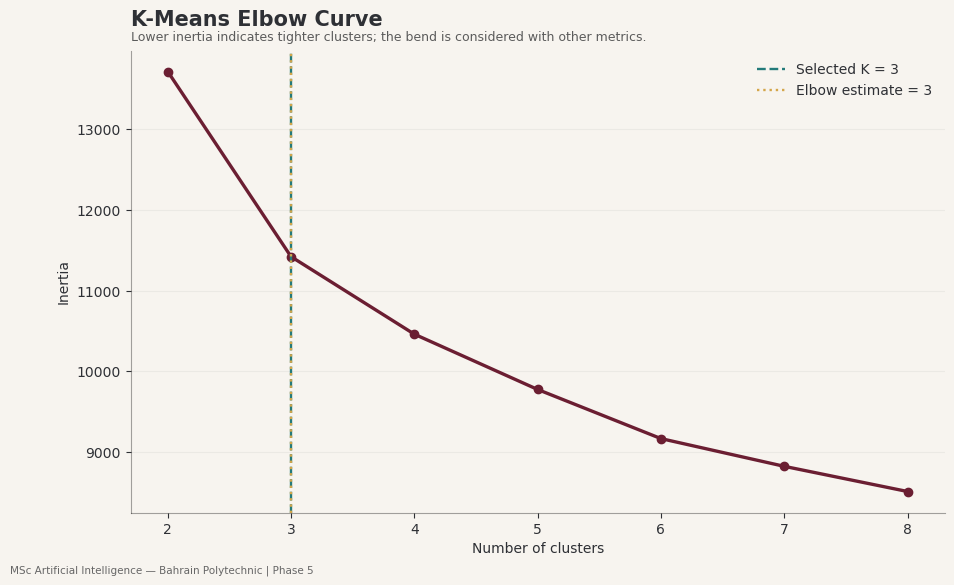

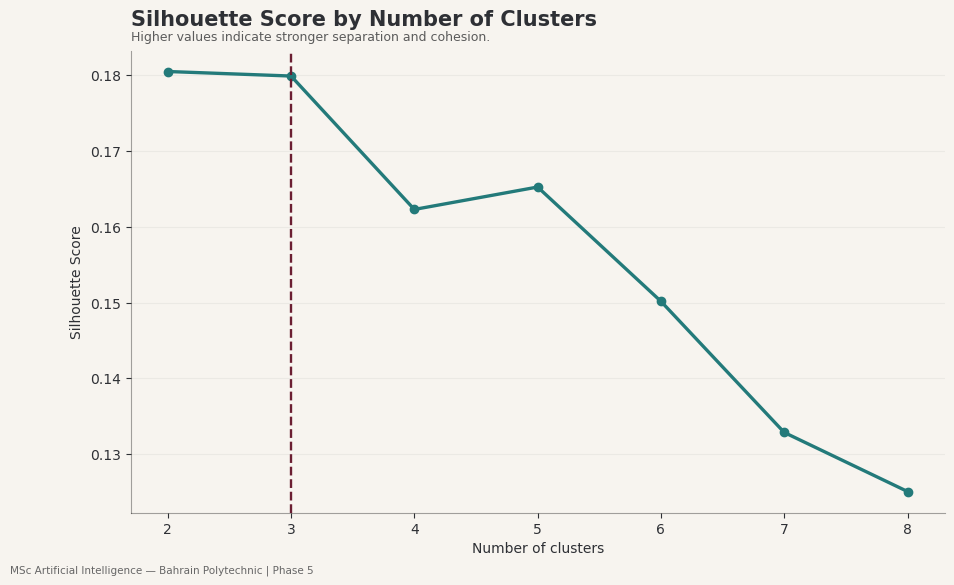

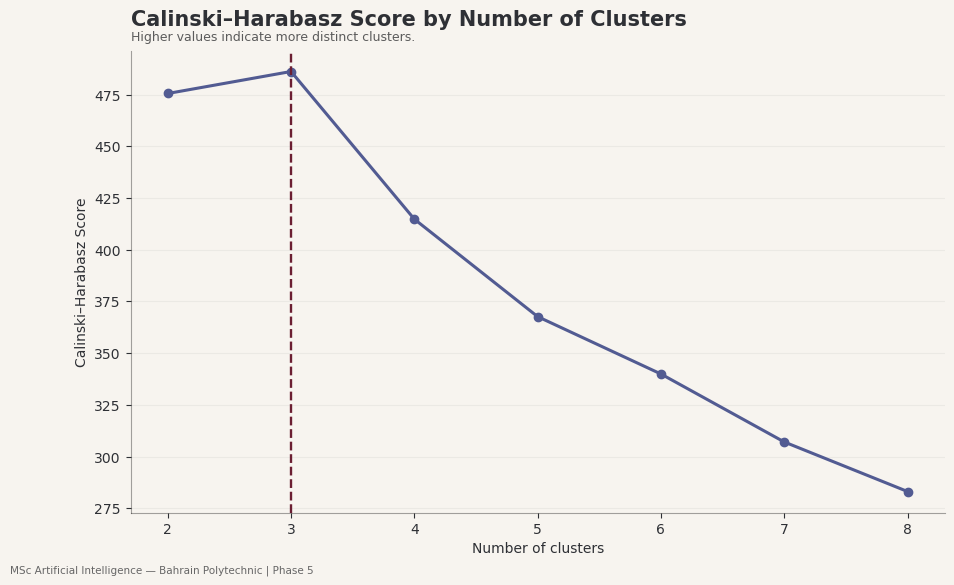

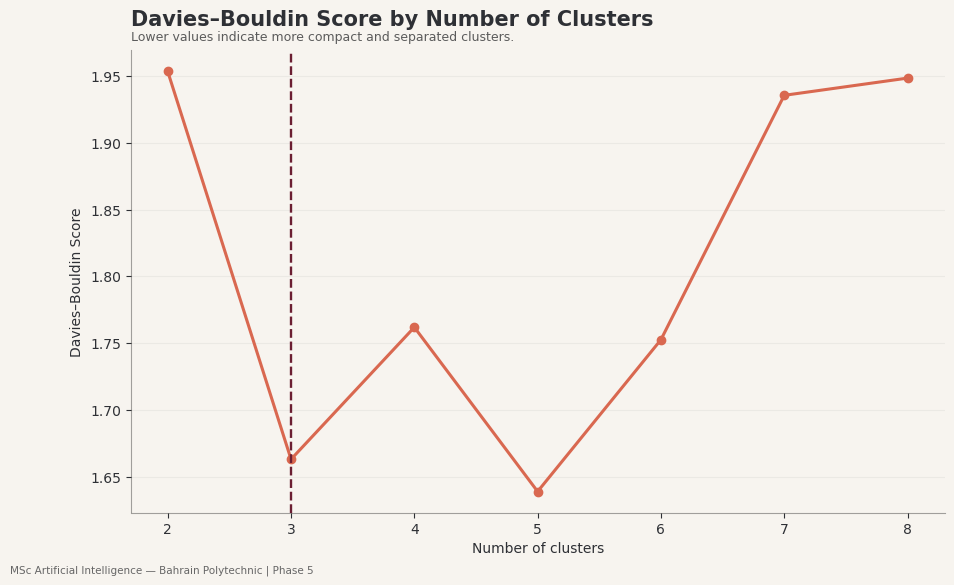

In [14]:
# Cell 5.9.1 — Visualise Elbow and Internal Validation Metrics

CELL_FOLDERS = create_cell_folders(
    "05_09",
    "Multiple_Visualization_Unsupervised_Analysis",
    "05_09_01",
    "Visualise_Elbow_and_Internal_Validation_Metrics",
)

figure, axis = plt.subplots(figsize=(10.5, 6))
axis.plot(
    cluster_number_evaluation["number_of_clusters"],
    cluster_number_evaluation["inertia"],
    marker="o",
    linewidth=2.4,
    color=THEME["maroon"],
)
axis.axvline(
    SELECTED_CLUSTER_COUNT,
    color=THEME["teal"],
    linestyle="--",
    linewidth=1.7,
    label=f"Selected K = {SELECTED_CLUSTER_COUNT}",
)
axis.axvline(
    elbow_cluster_count,
    color=THEME["gold"],
    linestyle=":",
    linewidth=1.7,
    label=f"Elbow estimate = {elbow_cluster_count}",
)
style_axis(
    axis,
    "K-Means Elbow Curve",
    "Lower inertia indicates tighter clusters; the bend is considered with other metrics.",
)
axis.set_xlabel("Number of clusters")
axis.set_ylabel("Inertia")
axis.legend()
save_figure(
    figure,
    CELL_FOLDERS,
    "05_09_01_elbow_curve",
)
plt.show()

figure, axis = plt.subplots(figsize=(10.5, 6))
axis.plot(
    cluster_number_evaluation["number_of_clusters"],
    cluster_number_evaluation["silhouette_score"],
    marker="o",
    linewidth=2.4,
    color=THEME["teal"],
)
axis.axvline(
    SELECTED_CLUSTER_COUNT,
    color=THEME["maroon"],
    linestyle="--",
    linewidth=1.7,
)
style_axis(
    axis,
    "Silhouette Score by Number of Clusters",
    "Higher values indicate stronger separation and cohesion.",
)
axis.set_xlabel("Number of clusters")
axis.set_ylabel("Silhouette Score")
save_figure(
    figure,
    CELL_FOLDERS,
    "05_09_01_silhouette_curve",
)
plt.show()

figure, axis = plt.subplots(figsize=(10.5, 6))
axis.plot(
    cluster_number_evaluation["number_of_clusters"],
    cluster_number_evaluation["calinski_harabasz_score"],
    marker="o",
    linewidth=2.2,
    color=THEME["indigo"],
    label="Calinski–Harabasz",
)
axis.set_xlabel("Number of clusters")
axis.set_ylabel("Calinski–Harabasz Score")
style_axis(
    axis,
    "Calinski–Harabasz Score by Number of Clusters",
    "Higher values indicate more distinct clusters.",
)
axis.axvline(
    SELECTED_CLUSTER_COUNT,
    color=THEME["maroon"],
    linestyle="--",
    linewidth=1.7,
)
save_figure(
    figure,
    CELL_FOLDERS,
    "05_09_01_calinski_curve",
)
plt.show()

figure, axis = plt.subplots(figsize=(10.5, 6))
axis.plot(
    cluster_number_evaluation["number_of_clusters"],
    cluster_number_evaluation["davies_bouldin_score"],
    marker="o",
    linewidth=2.2,
    color=THEME["coral"],
)
axis.set_xlabel("Number of clusters")
axis.set_ylabel("Davies–Bouldin Score")
style_axis(
    axis,
    "Davies–Bouldin Score by Number of Clusters",
    "Lower values indicate more compact and separated clusters.",
)
axis.axvline(
    SELECTED_CLUSTER_COUNT,
    color=THEME["maroon"],
    linestyle="--",
    linewidth=1.7,
)
save_figure(
    figure,
    CELL_FOLDERS,
    "05_09_01_davies_bouldin_curve",
)
plt.show()

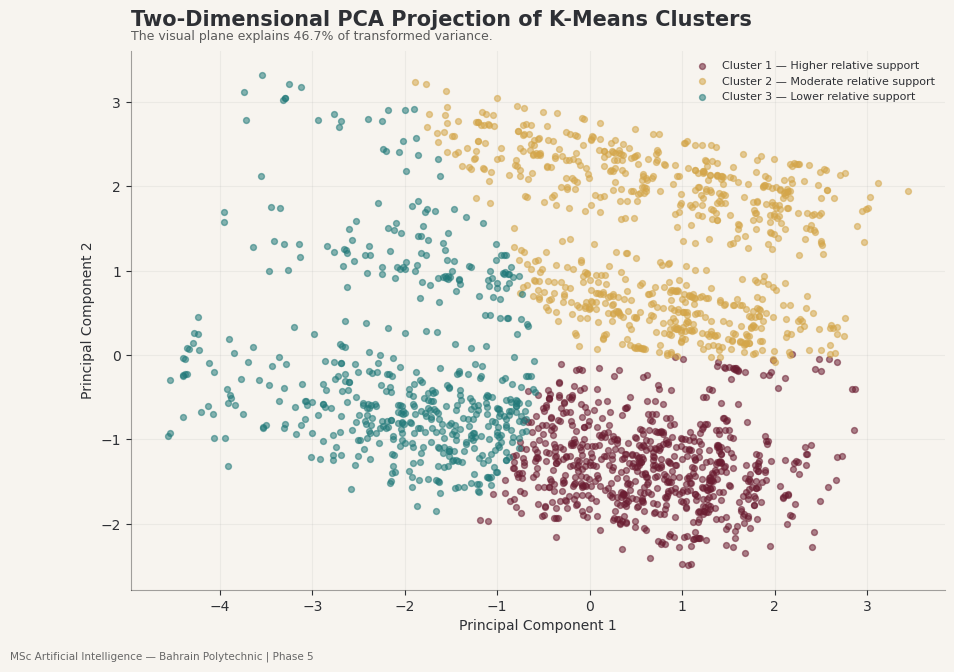

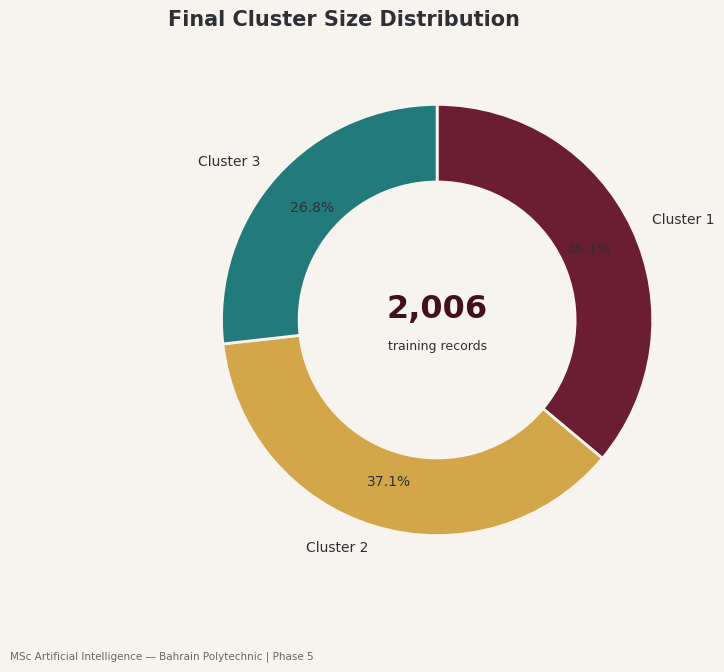

In [15]:
# Cell 5.9.2 — Visualise PCA Cluster Projection and Cluster Sizes

CELL_FOLDERS = create_cell_folders(
    "05_09",
    "Multiple_Visualization_Unsupervised_Analysis",
    "05_09_02",
    "Visualise_PCA_Cluster_Projection_and_Cluster_Sizes",
)

figure, axis = plt.subplots(figsize=(10.5, 7))

for cluster_id in sorted(
    cluster_assignments["cluster_id"].unique()
):
    subset = cluster_assignments[
        cluster_assignments["cluster_id"] == cluster_id
    ]
    axis.scatter(
        subset["pca_component_1"],
        subset["pca_component_2"],
        s=18,
        alpha=0.55,
        color=CLUSTER_COLORS[(cluster_id - 1) % len(CLUSTER_COLORS)],
        label=cluster_name_mapping[int(cluster_id)],
    )

style_axis(
    axis,
    "Two-Dimensional PCA Projection of K-Means Clusters",
    (
        f"The visual plane explains "
        f"{pca_two_dimensions.explained_variance_ratio_.sum() * 100:.1f}% "
        f"of transformed variance."
    ),
    grid_axis="both",
)
axis.set_xlabel("Principal Component 1")
axis.set_ylabel("Principal Component 2")
axis.legend(
    loc="best",
    fontsize=8,
)
save_figure(
    figure,
    CELL_FOLDERS,
    "05_09_02_pca_cluster_scatter",
)
plt.show()

figure, axis = plt.subplots(figsize=(8.5, 7))
axis.pie(
    cluster_size_table["record_count"],
    labels=[
        f"Cluster {cluster_id}"
        for cluster_id in cluster_size_table["cluster_id"]
    ],
    colors=[
        CLUSTER_COLORS[(cluster_id - 1) % len(CLUSTER_COLORS)]
        for cluster_id in cluster_size_table["cluster_id"]
    ],
    startangle=90,
    counterclock=False,
    autopct=lambda percentage: f"{percentage:.1f}%",
    pctdistance=0.78,
    wedgeprops={
        "width": 0.36,
        "edgecolor": THEME["warm_white"],
        "linewidth": 2,
    },
)
axis.text(
    0,
    0.05,
    f"{len(cluster_assignments):,}",
    ha="center",
    va="center",
    fontsize=23,
    fontweight="bold",
    color=THEME["deep_maroon"],
)
axis.text(
    0,
    -0.12,
    "training records",
    ha="center",
    va="center",
    fontsize=9,
)
axis.set_title(
    "Final Cluster Size Distribution",
    loc="left",
    pad=18,
    fontweight="bold",
)
save_figure(
    figure,
    CELL_FOLDERS,
    "05_09_02_cluster_size_donut",
)
plt.show()

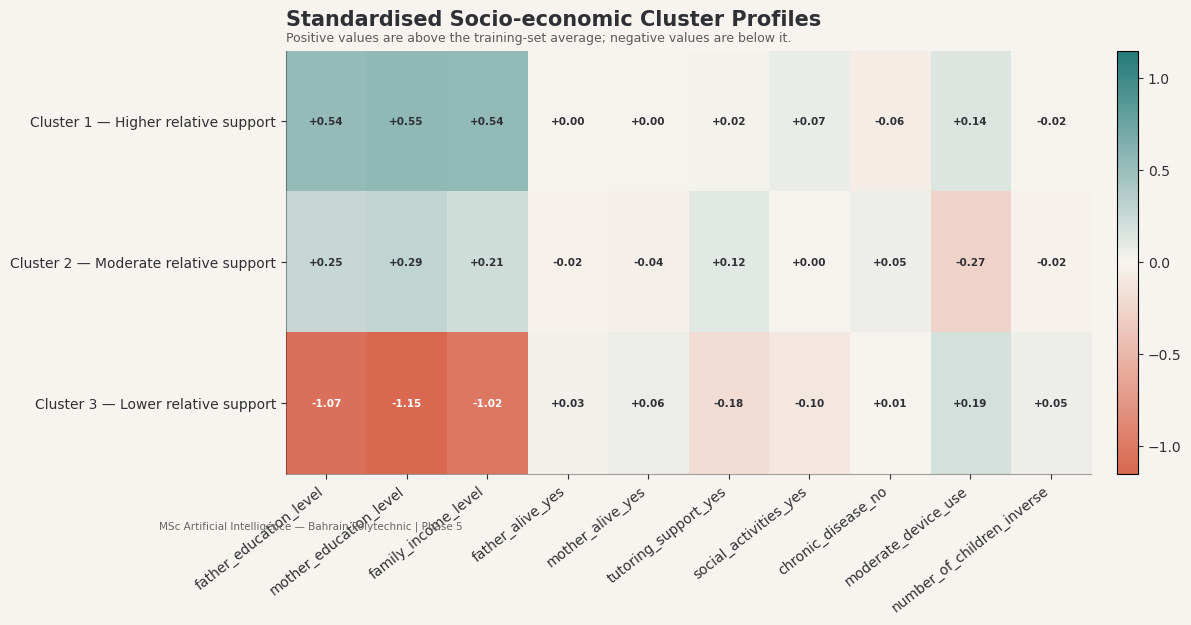

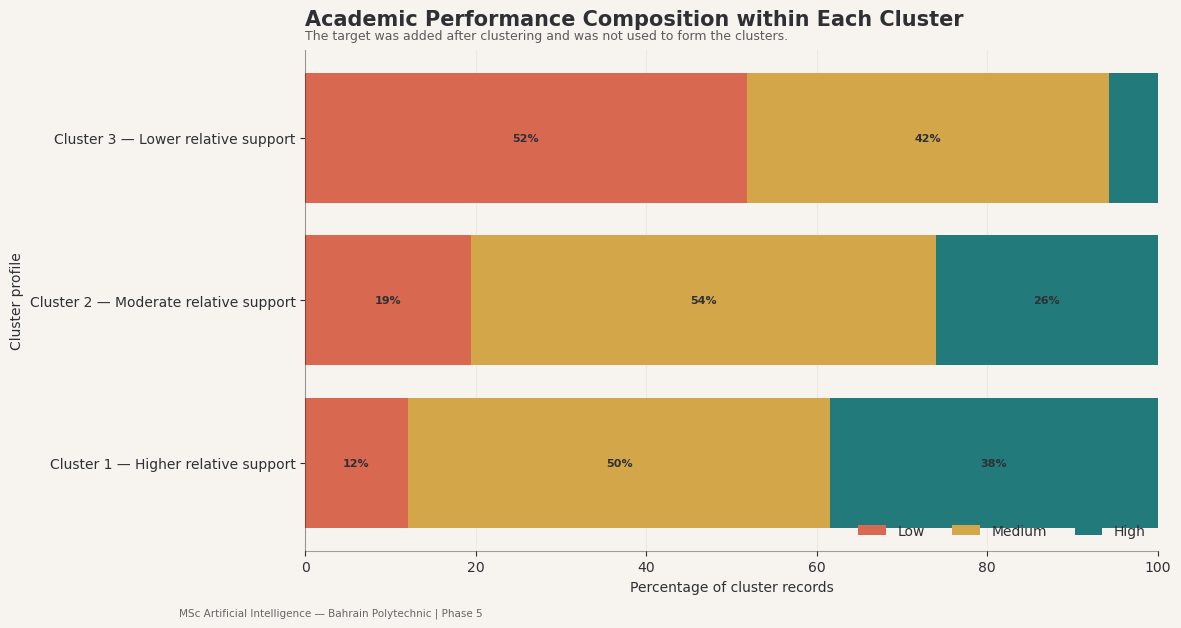

In [16]:
# Cell 5.9.3 — Visualise Cluster Profiles and Target Composition

CELL_FOLDERS = create_cell_folders(
    "05_09",
    "Multiple_Visualization_Unsupervised_Analysis",
    "05_09_03",
    "Visualise_Cluster_Profiles_and_Target_Composition",
)

profile_heatmap = (
    cluster_indicator_profile
    .set_index("cluster_name")
    .drop(
        columns=[
            "cluster_id",
            "relative_support_index",
        ]
    )
)

values = profile_heatmap.to_numpy()

figure, axis = plt.subplots(
    figsize=(11, max(5.5, len(profile_heatmap) * 0.9))
)

maximum_absolute_value = max(
    np.abs(values).max(),
    0.01,
)

image = axis.imshow(
    values,
    aspect="auto",
    vmin=-maximum_absolute_value,
    vmax=maximum_absolute_value,
    cmap=LinearSegmentedColormap.from_list(
        "profile_diverging",
        [
            THEME["coral"],
            THEME["warm_white"],
            THEME["teal"],
        ],
    ),
)

axis.set_xticks(np.arange(len(profile_heatmap.columns)))
axis.set_xticklabels(
    profile_heatmap.columns,
    rotation=38,
    ha="right",
)
axis.set_yticks(np.arange(len(profile_heatmap.index)))
axis.set_yticklabels(profile_heatmap.index)

for row_index in range(values.shape[0]):
    for column_index in range(values.shape[1]):
        value = values[row_index, column_index]
        axis.text(
            column_index,
            row_index,
            f"{value:+.2f}",
            ha="center",
            va="center",
            fontsize=7.5,
            fontweight="bold",
            color=(
                "white"
                if abs(value) > maximum_absolute_value * 0.65
                else THEME["charcoal"]
            ),
        )

style_axis(
    axis,
    "Standardised Socio-economic Cluster Profiles",
    "Positive values are above the training-set average; negative values are below it.",
    grid_axis=None,
)
figure.colorbar(
    image,
    ax=axis,
    fraction=0.025,
    pad=0.03,
)
save_figure(
    figure,
    CELL_FOLDERS,
    "05_09_03_cluster_profile_heatmap",
)
plt.show()

target_plot = cluster_target_percentages.reindex(
    columns=["Low", "Medium", "High"],
    fill_value=0,
)

figure, axis = plt.subplots(figsize=(11, 6.5))
left = np.zeros(len(target_plot))

for class_name in ["Low", "Medium", "High"]:
    values_for_class = target_plot[class_name].to_numpy()

    axis.barh(
        target_plot.index,
        values_for_class,
        left=left,
        color=CLASS_COLORS[class_name],
        label=class_name,
    )

    for row_index, (left_value, class_value) in enumerate(
        zip(left, values_for_class)
    ):
        if class_value >= 7:
            axis.text(
                left_value + class_value / 2,
                row_index,
                f"{class_value:.0f}%",
                ha="center",
                va="center",
                fontsize=8,
                fontweight="bold",
            )

    left += values_for_class

style_axis(
    axis,
    "Academic Performance Composition within Each Cluster",
    "The target was added after clustering and was not used to form the clusters.",
    grid_axis="x",
)
axis.set_xlabel("Percentage of cluster records")
axis.set_ylabel("Cluster profile")
axis.set_xlim(0, 100)
axis.legend(ncol=3, loc="lower right")
save_figure(
    figure,
    CELL_FOLDERS,
    "05_09_03_cluster_target_stacked_percentage",
)
plt.show()

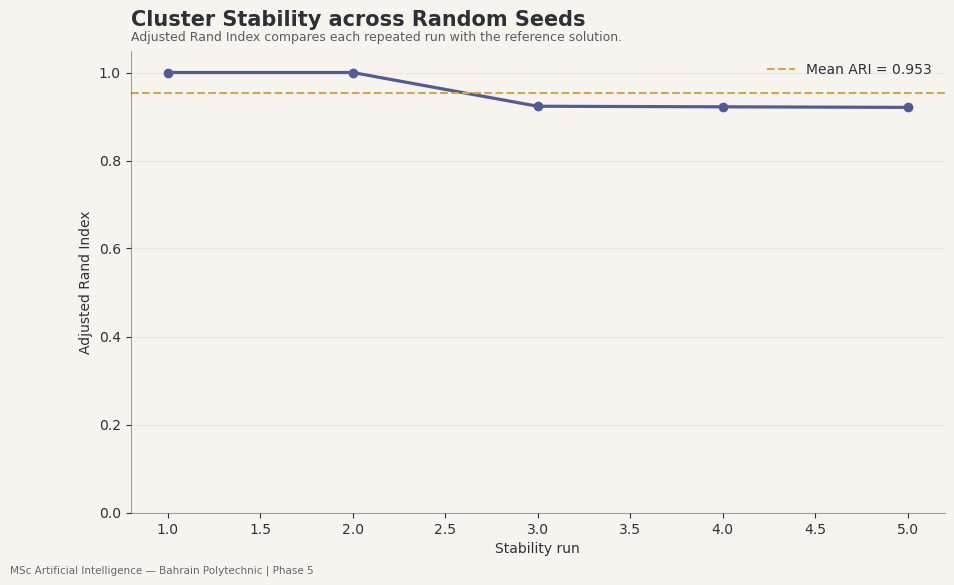

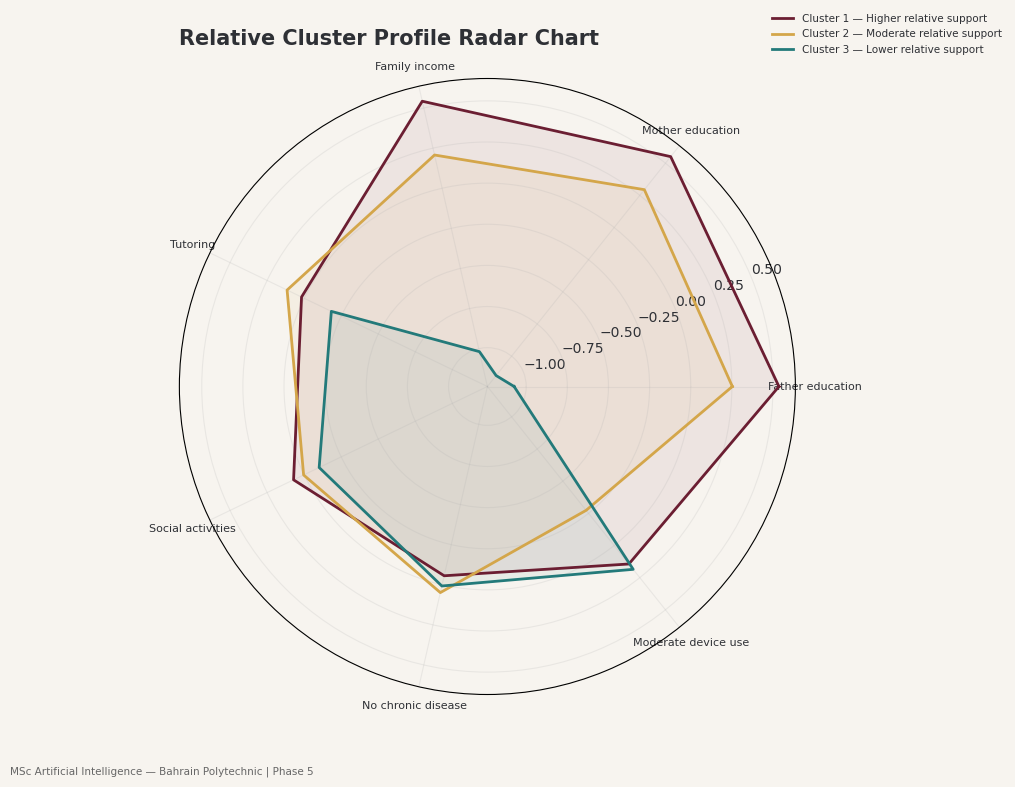

In [17]:
# Cell 5.9.4 — Visualise Cluster Stability and Radar Profiles

CELL_FOLDERS = create_cell_folders(
    "05_09",
    "Multiple_Visualization_Unsupervised_Analysis",
    "05_09_04",
    "Visualise_Cluster_Stability_and_Radar_Profiles",
)

figure, axis = plt.subplots(figsize=(10.5, 6))
axis.plot(
    cluster_stability_results["run_number"],
    cluster_stability_results[
        "adjusted_rand_index_against_reference"
    ],
    marker="o",
    linewidth=2.3,
    color=THEME["indigo"],
)
axis.axhline(
    cluster_stability_results[
        "adjusted_rand_index_against_reference"
    ].mean(),
    color=THEME["gold"],
    linestyle="--",
    linewidth=1.5,
    label=(
        "Mean ARI = "
        f"{cluster_stability_results['adjusted_rand_index_against_reference'].mean():.3f}"
    ),
)
style_axis(
    axis,
    "Cluster Stability across Random Seeds",
    "Adjusted Rand Index compares each repeated run with the reference solution.",
)
axis.set_xlabel("Stability run")
axis.set_ylabel("Adjusted Rand Index")
axis.set_ylim(0, 1.05)
axis.legend()
save_figure(
    figure,
    CELL_FOLDERS,
    "05_09_04_cluster_stability",
)
plt.show()

radar_variables = [
    "father_education_level",
    "mother_education_level",
    "family_income_level",
    "tutoring_support_yes",
    "social_activities_yes",
    "chronic_disease_no",
    "moderate_device_use",
]

radar_profile = (
    cluster_indicator_profile
    .set_index("cluster_name")[radar_variables]
)

angles = np.linspace(
    0,
    2 * np.pi,
    len(radar_variables),
    endpoint=False,
).tolist()
angles += angles[:1]

figure = plt.figure(figsize=(9.5, 8))
axis = figure.add_subplot(111, polar=True)

for cluster_number, (cluster_name, row) in enumerate(
    radar_profile.iterrows()
):
    values_for_cluster = row.to_list()
    values_for_cluster += values_for_cluster[:1]

    axis.plot(
        angles,
        values_for_cluster,
        linewidth=2,
        color=CLUSTER_COLORS[
            cluster_number % len(CLUSTER_COLORS)
        ],
        label=cluster_name,
    )
    axis.fill(
        angles,
        values_for_cluster,
        alpha=0.07,
        color=CLUSTER_COLORS[
            cluster_number % len(CLUSTER_COLORS)
        ],
    )

axis.set_xticks(angles[:-1])
axis.set_xticklabels(
    [
        "Father education",
        "Mother education",
        "Family income",
        "Tutoring",
        "Social activities",
        "No chronic disease",
        "Moderate device use",
    ],
    fontsize=8,
)
axis.set_title(
    "Relative Cluster Profile Radar Chart",
    loc="left",
    pad=24,
    fontweight="bold",
)
axis.grid(alpha=0.2)
axis.legend(
    loc="upper right",
    bbox_to_anchor=(1.35, 1.12),
    fontsize=7.5,
)
save_figure(
    figure,
    CELL_FOLDERS,
    "05_09_04_cluster_radar",
)
plt.show()

In [18]:
# Cell 5.9.5 — Create the Phase 5 Visualisation Catalogue

CELL_FOLDERS = create_cell_folders(
    "05_09",
    "Multiple_Visualization_Unsupervised_Analysis",
    "05_09_05",
    "Create_the_Phase_5_Visualisation_Catalogue",
)

figure_files = sorted(PHASE_DIR.rglob("*.png"))

visualisation_catalogue = pd.DataFrame(
    [
        {
            "figure_number": number,
            "figure_name": path.stem,
            "relative_path": str(path.relative_to(PHASE_DIR)),
            "file_size_kb": round(path.stat().st_size / 1024, 2),
        }
        for number, path in enumerate(
            figure_files,
            start=1,
        )
    ]
)

save_dataframe(
    visualisation_catalogue,
    CELL_FOLDERS,
    "05_09_05_visualisation_catalogue",
)

display(visualisation_catalogue)

,figure_number,figure_name,relative_path,file_size_kb
0,1,05_09_01_calinski_curve,Section_05_09_Multiple_Visualization_Unsupervi...,187.23
1,2,05_09_01_davies_bouldin_curve,Section_05_09_Multiple_Visualization_Unsupervi...,197.98
2,3,05_09_01_elbow_curve,Section_05_09_Multiple_Visualization_Unsupervi...,177.26
3,4,05_09_01_silhouette_curve,Section_05_09_Multiple_Visualization_Unsupervi...,165.54
4,5,05_09_02_cluster_size_donut,Section_05_09_Multiple_Visualization_Unsupervi...,147.49
5,6,05_09_02_pca_cluster_scatter,Section_05_09_Multiple_Visualization_Unsupervi...,959.12
6,7,05_09_03_cluster_profile_heatmap,Section_05_09_Multiple_Visualization_Unsupervi...,418.38
7,8,05_09_03_cluster_target_stacked_percentage,Section_05_09_Multiple_Visualization_Unsupervi...,190.29
8,9,05_09_04_cluster_radar,Section_05_09_Multiple_Visualization_Unsupervi...,602.04
9,10,05_09_04_cluster_stability,Section_05_09_Multiple_Visualization_Unsupervi...,142.79


# Section 5.10 — Export Multiple Files and Phase Handoff

**Purpose:** Export cluster assignments, profiles, selection metrics, stability results, fitted preprocessing/PCA/K-Means models, a consolidated report package, and a Phase 6 handoff manifest.

In [19]:
# Cell 5.10.1 — Export Official Phase 5 Tables and Models

CELL_FOLDERS = create_cell_folders(
    "05_10",
    "Export_Multiple_Files_and_Phase_Handoff",
    "05_10_01",
    "Export_Official_Phase_5_Tables_and_Models",
)

FINAL_CLUSTER_ASSIGNMENTS_CSV = (
    DATA_DIR / "phase_05_cluster_assignments.csv"
)
FINAL_CLUSTER_PROFILES_CSV = (
    DATA_DIR / "phase_05_cluster_profiles.csv"
)
FINAL_CLUSTER_EVALUATION_CSV = (
    DATA_DIR / "phase_05_cluster_evaluation.csv"
)
FINAL_CLUSTER_TARGET_CSV = (
    DATA_DIR / "phase_05_cluster_target_comparison.csv"
)
FINAL_CLUSTER_SELECTION_CSV = (
    DATA_DIR / "phase_05_cluster_number_selection.csv"
)
FINAL_CLUSTER_STABILITY_CSV = (
    DATA_DIR / "phase_05_cluster_stability.csv"
)

cluster_assignments.to_csv(
    FINAL_CLUSTER_ASSIGNMENTS_CSV,
    index=False,
    encoding="utf-8-sig",
)
cluster_indicator_profile.to_csv(
    FINAL_CLUSTER_PROFILES_CSV,
    index=False,
    encoding="utf-8-sig",
)
cluster_evaluation_summary.to_csv(
    FINAL_CLUSTER_EVALUATION_CSV,
    index=False,
    encoding="utf-8-sig",
)
cluster_target_percentages.reset_index().to_csv(
    FINAL_CLUSTER_TARGET_CSV,
    index=False,
    encoding="utf-8-sig",
)
cluster_number_evaluation.to_csv(
    FINAL_CLUSTER_SELECTION_CSV,
    index=False,
    encoding="utf-8-sig",
)
cluster_stability_results.to_csv(
    FINAL_CLUSTER_STABILITY_CSV,
    index=False,
    encoding="utf-8-sig",
)

official_files = [
    FINAL_CLUSTER_ASSIGNMENTS_CSV,
    FINAL_CLUSTER_PROFILES_CSV,
    FINAL_CLUSTER_EVALUATION_CSV,
    FINAL_CLUSTER_TARGET_CSV,
    FINAL_CLUSTER_SELECTION_CSV,
    FINAL_CLUSTER_STABILITY_CSV,
    PREPROCESSOR_MODEL_PATH,
    PCA_MODEL_PATH,
    PCA_2D_MODEL_PATH,
    KMEANS_MODEL_PATH,
]

for source_path in official_files:
    shutil.copy2(
        source_path,
        CELL_FOLDERS["files"] / source_path.name,
    )

export_summary = pd.DataFrame(
    [
        {
            "artifact": path.name,
            "official_path": str(path),
            "file_size_kb": round(path.stat().st_size / 1024, 2),
            "sha256": sha256_file(path),
        }
        for path in official_files
    ]
)

save_dataframe(
    export_summary,
    CELL_FOLDERS,
    "05_10_01_export_summary",
)

display(export_summary)

,artifact,official_path,file_size_kb,sha256
0,phase_05_cluster_assignments.csv,C:\Users\User\Desktop\All\data\phase_05_cluste...,329.75,00f08f374e2cb5ab53a3e81a89b800deb9189ddbfc66d5...
1,phase_05_cluster_profiles.csv,C:\Users\User\Desktop\All\data\phase_05_cluste...,1.03,ee3e84db08e8d44d5fc773bc783c03312c71f6c0315978...
2,phase_05_cluster_evaluation.csv,C:\Users\User\Desktop\All\data\phase_05_cluste...,0.32,6ad2fe799a558c52f46a1bc4d1edc3234dde32c69629a8...
3,phase_05_cluster_target_comparison.csv,C:\Users\User\Desktop\All\data\phase_05_cluste...,0.31,bc6a06faf83ced9a3292fe000ccbd7ca25072f1e4850ba...
4,phase_05_cluster_number_selection.csv,C:\Users\User\Desktop\All\data\phase_05_cluste...,1.08,60b4ac3cb97d3d26e2f93433277c663fcc95f1d0214d2a...
5,phase_05_cluster_stability.csv,C:\Users\User\Desktop\All\data\phase_05_cluste...,0.37,5ca74a7e802f50849b19fcee1313945ac1e37a3f1fa899...
6,phase_05_fitted_clustering_preprocessor.joblib,C:\Users\User\Desktop\All\outputs\Phase_05_Uns...,11.30,76fdb4c3b8465d1a081f135dc66d7006a0cd10f99fa67c...
7,phase_05_selected_pca.joblib,C:\Users\User\Desktop\All\outputs\Phase_05_Uns...,3.62,ae522c6d6afdf56177118244196ca7806b960ebb0a5402...
8,phase_05_two_dimensional_pca.joblib,C:\Users\User\Desktop\All\outputs\Phase_05_Uns...,1.58,7b20b1830473be462374ee8ac95bda912a406da1ee0789...
9,phase_05_final_kmeans.joblib,C:\Users\User\Desktop\All\outputs\Phase_05_Uns...,8.81,79de2e54941c0dd2a0565661522a74acadb18a32b2780e...


In [20]:
# Cell 5.10.2 — Create Consolidated CSV Report Directory

CELL_FOLDERS = create_cell_folders(
    "05_10",
    "Export_Multiple_Files_and_Phase_Handoff",
    "05_10_02",
    "Create_Consolidated_CSV_Report_Directory",
)

CONSOLIDATED_REPORT_DIR = (
    CELL_FOLDERS["files"]
    / "phase_05_consolidated_reports"
)
CONSOLIDATED_REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

report_tables = {
    "project_configuration": pd.DataFrame(
        [project_configuration]
    ),
    "library_versions": library_versions,
    "variable_roles": role_table,
    "transformation_summary": transformation_summary,
    "pca_summary": pca_summary,
    "pca_explained_variance": pca_variance_table,
    "cluster_number_evaluation": cluster_number_evaluation,
    "cluster_size_table": cluster_size_table,
    "cluster_evaluation_summary": cluster_evaluation_summary,
    "cluster_stability_results": cluster_stability_results,
    "cluster_stability_summary": cluster_stability_summary,
    "numeric_cluster_profile": numeric_cluster_profile,
    "categorical_cluster_profile": categorical_cluster_profile,
    "standardised_cluster_profile": cluster_indicator_profile,
    "cluster_names": cluster_name_table,
    "cluster_target_percentages": cluster_target_percentages.reset_index(),
    "cluster_target_association": cluster_target_association,
    "visualisation_catalogue": visualisation_catalogue,
    "export_summary": export_summary,
}

for report_name, dataframe in report_tables.items():
    dataframe.to_csv(
        CONSOLIDATED_REPORT_DIR / f"{report_name}.csv",
        index=False,
        encoding="utf-8-sig",
    )

print("Consolidated CSV report directory:", CONSOLIDATED_REPORT_DIR)

Consolidated CSV report directory: C:\Users\User\Desktop\All\outputs\Phase_05_Unsupervised_Learning_Analysis\Section_05_10_Export_Multiple_Files_and_Phase_Handoff\Cell_05_10_02_Create_Consolidated_CSV_Report_Directory\files\phase_05_consolidated_reports


In [21]:
# Cell 5.10.3 — Create Phase 6 Handoff Manifest and Final Quality Checks

CELL_FOLDERS = create_cell_folders(
    "05_10",
    "Export_Multiple_Files_and_Phase_Handoff",
    "05_10_03",
    "Create_Phase_6_Handoff_Manifest_and_Final_Quality_Checks",
)

quality_checks = []


def add_quality_check(name, passed, details):
    quality_checks.append(
        {
            "quality_check": name,
            "passed": bool(passed),
            "details": str(details),
        }
    )


add_quality_check(
    "Target excluded from clustering predictors",
    TARGET_COLUMN not in PREDICTOR_COLUMNS,
    TARGET_COLUMN,
)

add_quality_check(
    "Identifiers excluded from clustering predictors",
    (
        ID_COLUMN not in PREDICTOR_COLUMNS
        and GROUP_COLUMN not in PREDICTOR_COLUMNS
    ),
    [ID_COLUMN, GROUP_COLUMN],
)

add_quality_check(
    "Cluster assignment exists for every training record",
    len(cluster_assignments) == len(training_data),
    f"{len(cluster_assignments)} of {len(training_data)}",
)

add_quality_check(
    "Every selected cluster contains at least 5% of records",
    bool((cluster_size_table["percentage"] >= 5).all()),
    cluster_size_table[
        ["cluster_id", "percentage"]
    ].to_dict(orient="records"),
)

add_quality_check(
    "All final transformed values are finite",
    bool(np.isfinite(X_pca).all()),
    X_pca.shape,
)

add_quality_check(
    "Fitted clustering models exist",
    all(
        path.exists()
        for path in [
            PREPROCESSOR_MODEL_PATH,
            PCA_MODEL_PATH,
            PCA_2D_MODEL_PATH,
            KMEANS_MODEL_PATH,
        ]
    ),
    [
        str(PREPROCESSOR_MODEL_PATH),
        str(PCA_MODEL_PATH),
        str(KMEANS_MODEL_PATH),
    ],
)

add_quality_check(
    "Holdout test was not used",
    True,
    phase_4_manifest.get("holdout_test_used", False),
)

phase_5_quality_checks = pd.DataFrame(
    quality_checks
)

save_dataframe(
    phase_5_quality_checks,
    CELL_FOLDERS,
    "05_10_03_phase_5_quality_checks",
)
save_json_report(
    quality_checks,
    CELL_FOLDERS,
    "05_10_03_phase_5_quality_checks",
)

if not phase_5_quality_checks["passed"].all():
    failed_checks = phase_5_quality_checks.loc[
        ~phase_5_quality_checks["passed"],
        "quality_check",
    ].tolist()
    raise AssertionError(
        "Phase 5 quality checks failed: "
        + "; ".join(failed_checks)
    )

phase_6_handoff = {
    "completed_phase": "Phase 5 — Unsupervised Learning Analysis",
    "next_phase": "Phase 6 — Model Comparison and Quality Checking",
    "training_dataset": str(TRAINING_DATA_PATH),
    "cluster_assignments": str(FINAL_CLUSTER_ASSIGNMENTS_CSV),
    "cluster_profiles": str(FINAL_CLUSTER_PROFILES_CSV),
    "cluster_evaluation": str(FINAL_CLUSTER_EVALUATION_CSV),
    "cluster_target_comparison": str(FINAL_CLUSTER_TARGET_CSV),
    "cluster_number_selection": str(FINAL_CLUSTER_SELECTION_CSV),
    "cluster_stability": str(FINAL_CLUSTER_STABILITY_CSV),
    "clustering_preprocessor": str(PREPROCESSOR_MODEL_PATH),
    "pca_model": str(PCA_MODEL_PATH),
    "pca_2d_model": str(PCA_2D_MODEL_PATH),
    "kmeans_model": str(KMEANS_MODEL_PATH),
    "selected_cluster_count": SELECTED_CLUSTER_COUNT,
    "cluster_names": cluster_name_mapping,
    "silhouette_score": FINAL_SILHOUETTE,
    "calinski_harabasz_score": FINAL_CALINSKI,
    "davies_bouldin_score": FINAL_DAVIES,
    "mean_stability_ari": float(
        cluster_stability_results[
            "adjusted_rand_index_against_reference"
        ].mean()
    ),
    "cramers_v_with_academic_class": cramers_v,
    "target_used_during_clustering": False,
    "holdout_test_used": False,
    "generated_at": datetime.now().isoformat(),
}

PHASE_6_HANDOFF_PATH = save_json_report(
    phase_6_handoff,
    CELL_FOLDERS,
    "phase_05_handoff_manifest_for_phase_06",
)

with (
    PHASE_DIR / "phase_05_handoff_manifest_for_phase_06.json"
).open("w", encoding="utf-8") as file:
    json.dump(
        phase_6_handoff,
        file,
        ensure_ascii=False,
        indent=2,
    )

display(phase_5_quality_checks)
print("Phase 6 handoff:", PHASE_6_HANDOFF_PATH)

,quality_check,passed,details
0,Target excluded from clustering predictors,True,academic_performance_class
1,Identifiers excluded from clustering predictors,True,"['student_record_id', 'family_id']"
2,Cluster assignment exists for every training r...,True,2006 of 2006
3,Every selected cluster contains at least 5% of...,True,"[{'cluster_id': 1, 'percentage': 36.092}, {'cl..."
4,All final transformed values are finite,True,"(2006, 11)"
5,Fitted clustering models exist,True,['C:\\Users\\User\\Desktop\\All\\outputs\\Phas...
6,Holdout test was not used,True,False


Phase 6 handoff: C:\Users\User\Desktop\All\outputs\Phase_05_Unsupervised_Learning_Analysis\Section_05_10_Export_Multiple_Files_and_Phase_Handoff\Cell_05_10_03_Create_Phase_6_Handoff_Manifest_and_Final_Quality_Checks\reports\phase_05_handoff_manifest_for_phase_06.json


In [22]:
# Cell 5.10.4 — Create Completion Summary and Complete ZIP Archive

CELL_FOLDERS = create_cell_folders(
    "05_10",
    "Export_Multiple_Files_and_Phase_Handoff",
    "05_10_04",
    "Create_Completion_Summary_and_Complete_ZIP_Archive",
)

mean_stability_ari = float(
    cluster_stability_results[
        "adjusted_rand_index_against_reference"
    ].mean()
)

summary_text = f"""
PHASE 5 COMPLETION SUMMARY
{'=' * 76}

Training records:
{len(training_data):,}

Clustering inputs:
- Original predictors: {len(PREDICTOR_COLUMNS)}
- Transformed features: {X_transformed.shape[1]}
- PCA components retained: {selected_component_count}
- PCA variance retained: {pca_selected.explained_variance_ratio_.sum():.4f}

Final K-Means:
- Selected clusters: {SELECTED_CLUSTER_COUNT}
- Silhouette Score: {FINAL_SILHOUETTE:.4f}
- Calinski–Harabasz Score: {FINAL_CALINSKI:.4f}
- Davies–Bouldin Score: {FINAL_DAVIES:.4f}
- Mean stability ARI: {mean_stability_ari:.4f}

Post-clustering interpretation:
- Academic target used to form clusters: False
- Cramér's V with academic class: {cramers_v:.4f}
- Holdout test used: False

Cluster profiles:
{chr(10).join(
    f"- {row['cluster_name']}: {int(row['record_count'])} records "
    f"({row['percentage']:.1f}%)"
    for _, row in cluster_size_table.sort_values('cluster_id').iterrows()
)}
""".strip()

summary_path = (
    CELL_FOLDERS["reports"]
    / "05_10_04_phase_5_summary.txt"
)
summary_path.write_text(
    summary_text,
    encoding="utf-8",
)

ZIP_PATH = (
    CELL_FOLDERS["files"]
    / "05_10_04_phase_5_complete_export.zip"
)

with zipfile.ZipFile(
    ZIP_PATH,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as zip_file:
    for file_path in sorted(PHASE_DIR.rglob("*")):
        if not file_path.is_file() or file_path == ZIP_PATH:
            continue
        zip_file.write(
            file_path,
            file_path.relative_to(PHASE_DIR),
        )

print(summary_text)
print("\nComplete ZIP:", ZIP_PATH)

PHASE 5 COMPLETION SUMMARY

Training records:
2,006

Clustering inputs:
- Original predictors: 17
- Transformed features: 26
- PCA components retained: 11
- PCA variance retained: 0.9104

Final K-Means:
- Selected clusters: 3
- Silhouette Score: 0.1799
- Calinski–Harabasz Score: 486.1135
- Davies–Bouldin Score: 1.6629
- Mean stability ARI: 0.9532

Post-clustering interpretation:
- Academic target used to form clusters: False
- Cramér's V with academic class: 0.2948
- Holdout test used: False

Cluster profiles:
- Cluster 1 — Higher relative support: 724 records (36.1%)
- Cluster 2 — Moderate relative support: 745 records (37.1%)
- Cluster 3 — Lower relative support: 537 records (26.8%)

Complete ZIP: C:\Users\User\Desktop\All\outputs\Phase_05_Unsupervised_Learning_Analysis\Section_05_10_Export_Multiple_Files_and_Phase_Handoff\Cell_05_10_04_Create_Completion_Summary_and_Complete_ZIP_Archive\files\05_10_04_phase_5_complete_export.zip


# Phase 5 Completed

Phase 5 discovers natural profiles from the structured training variables without using the academic target during clustering.

```text
Phase 3 training data
        ↓
PCA + K-Means
        ↓
Cluster validation and stability
        ↓
Cluster profiling
        ↓
Post-clustering target interpretation
        ↓
Phase 6 quality analysis
```

The untouched holdout test set remains reserved for Phase 8.